<a href="https://colab.research.google.com/github/nirmaljb/deep-learning-notebooks/blob/main/RNN_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Bidirectional
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam

In [ ]:
df = yf.download("AAPL", period="5y", auto_adjust=True)[['Close']]
df.head(10)

[*********************100%***********************]  1 of 1 completed


Price,Close
Ticker,AAPL
Date,
2021-04-12,127.827217
2021-04-13,130.934189
2021-04-14,128.596634
2021-04-15,131.002396
2021-04-16,130.671265
2021-04-19,131.333588
2021-04-20,129.648560
2021-04-21,130.028427


In [ ]:
df.shape

(1256, 1)

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)
scaled_data

array([[0.04843255],
       [0.06713326],
       [0.05306363],
       ...,
       [0.83735314],
       [0.84692325],
       [0.84686318]])

In [ ]:
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

window_size = 30
X, y = create_sequences(scaled_data, window=window_size)

In [ ]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
X[0]

array([[0.04843255],
       [0.06713326],
       [0.05306363],
       [0.06754379],
       [0.06555073],
       [0.06953722],
       [0.05939512],
       [0.06168153],
       [0.05253609],
       [0.06648853],
       [0.06883344],
       [0.06689906],
       [0.06215029],
       [0.06156415],
       [0.04972206],
       [0.05605345],
       [0.02855861],
       [0.03002431],
       [0.03963864],
       [0.04369084],
       [0.02395949],
       [0.01843933],
       [0.        ],
       [0.0129194 ],
       [0.02748282],
       [0.02055339],
       [0.01221465],
       [0.01127497],
       [0.02666069],
       [0.01562065]])

In [ ]:
y[0]

array([0.02542749])

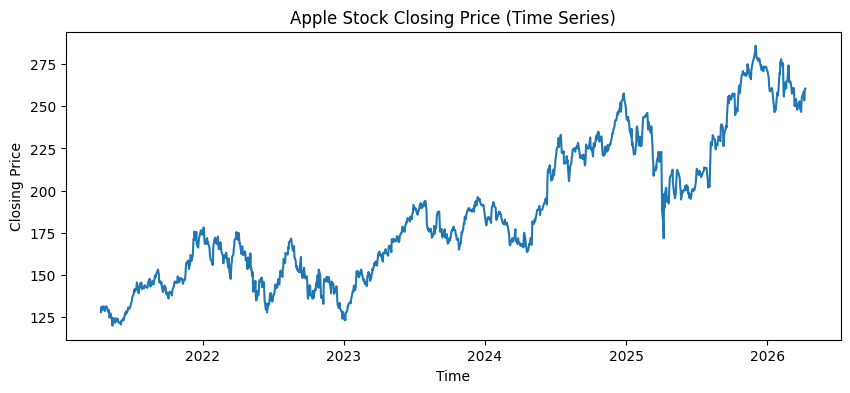

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(df['Close'])
plt.title("Apple Stock Closing Price (Time Series)")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.show()

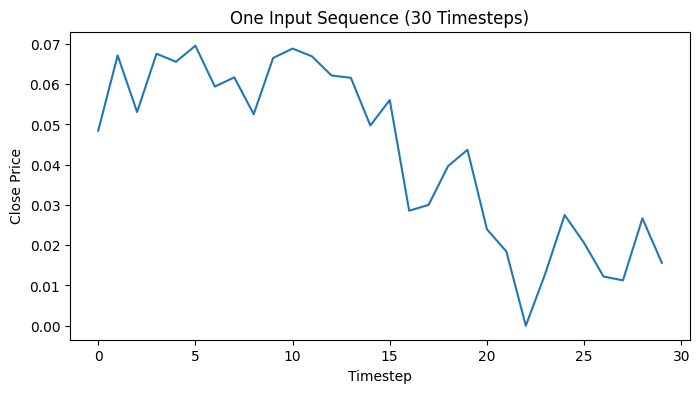

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(X[0])
plt.title("One Input Sequence (30 Timesteps)")
plt.xlabel("Timestep")
plt.ylabel("Close Price")
plt.show()

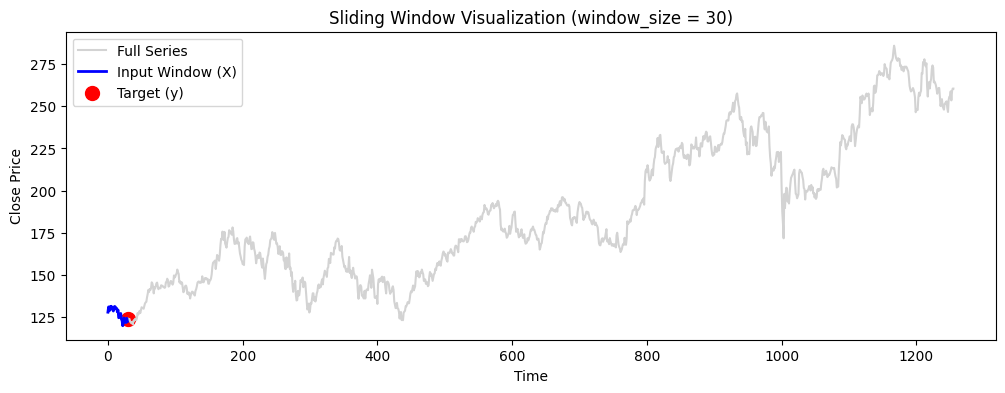

In [ ]:
i = 30

window_size = 30

plt.figure(figsize=(12,4))

# Full series
plt.plot(df['Close'].values, color='lightgray', label="Full Series")

# Sliding window (X)
plt.plot(range(i-window_size, i),df['Close'].values[i-window_size:i],color='blue',linewidth=2,label="Input Window (X)")

# Target value (y)
plt.scatter(i,df['Close'].values[i],color='red',s=100,label="Target (y)")
plt.title("Sliding Window Visualization (window_size = 30)")
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.show()

In [ ]:
model_rnn = Sequential([SimpleRNN(50, return_sequences=False, input_shape=(window_size, 1)),Dense(1)])

model_rnn.compile(optimizer="adam", loss="mse")
model_rnn.summary()

history_rnn = model_rnn.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0247 - val_loss: 0.0137
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - val_loss: 0.0031
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.6788e-04 - val_loss: 0.0021
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.7710e-04 - val_loss: 0.0023
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.0975e-04 - val_loss: 0.0014
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.6850e-04 - val_loss: 0.0017
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.8639e-04 - val_loss: 0.0015
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.5668e-04 - val_loss: 0.0021
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.9206e-04 - val_loss: 0.0014
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.9458e-04 - val_loss: 0.0024


In [ ]:
prediction = model_rnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f"Predicted: {prediction[i][0]:.2f}, Actual: {actual[i][0]:.2f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Predicted: 196.79, Actual: 196.13
Predicted: 197.51, Actual: 192.32
Predicted: 188.83, Actual: 198.87
Predicted: 193.00, Actual: 203.71
Predicted: 193.57, Actual: 207.47
Predicted: 204.60, Actual: 208.37
Predicted: 204.61, Actual: 209.23
Predicted: 205.65, Actual: 210.29
Predicted: 204.64, Actual: 211.58
Predicted: 209.00, Actual: 212.39
Predicted: 204.78, Actual: 204.46
Predicted: 205.53, Actual: 198.03
Predicted: 199.70, Actual: 197.65
Predicted: 199.73, Actual: 195.40
Predicted: 192.46, Actual: 196.63
Predicted: 198.39, Actual: 197.67
Predicted: 193.59, Actual: 210.15
Predicted: 198.78, Actual: 212.28
Predicted: 204.18, Actual: 211.69
Predicted: 208.06, Actual: 210.81
Predicted: 206.83, Actual: 210.62
Predicted: 209.45, Actual: 208.15
Predicted: 204.44, Actual: 206.23
Predicted: 206.58, Actual: 201.48
Predicted: 203.85, Actual: 200.75
Predicted: 201.44, Actual: 194.68
Predicted: 197.32, Actual: 199.60
Predicted: 198.25, Actual: 199.81
Predicted:

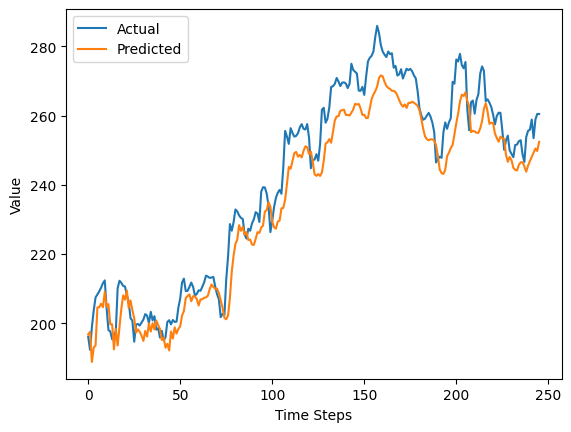

In [ ]:
plt.figure()
plt.plot(actual, label="Actual")
plt.plot(prediction, label="Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
model_deep_rnn = Sequential([SimpleRNN(50, return_sequences=True, input_shape=(window_size, 1)),SimpleRNN(50),Dense(1)])

model_deep_rnn.compile(optimizer="adam", loss="mse")
model_deep_rnn.summary()

history_deep = model_deep_rnn.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 30, 50)         │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,701 (30.08 KB)

 Trainable params: 7,701 (30.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0742 - val_loss: 0.0074
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044 - val_loss: 0.0059
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0020 - val_loss: 0.0054
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0017 - val_loss: 0.0046
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0015 - val_loss: 0.0044
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - val_loss: 0.0037
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0013 - val_loss: 0.0047
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - val_loss: 0.0027
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 - val_loss: 0.0029
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0012 - val_loss: 0.0032


In [ ]:
prediction = model_deep_rnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f"Predicted: {prediction[i][0]:.2f}, Actual: {actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
Predicted: 204.21, Actual: 196.13
Predicted: 194.69, Actual: 192.32
Predicted: 196.48, Actual: 198.87
Predicted: 197.01, Actual: 203.71
Predicted: 196.65, Actual: 207.47
Predicted: 200.86, Actual: 208.37
Predicted: 203.74, Actual: 209.23
Predicted: 203.46, Actual: 210.29
Predicted: 206.26, Actual: 211.58
Predicted: 208.03, Actual: 212.39
Predicted: 209.10, Actual: 204.46
Predicted: 207.05, Actual: 198.03
Predicted: 209.01, Actual: 197.65
Predicted: 204.82, Actual: 195.40
Predicted: 205.01, Actual: 196.63
Predicted: 202.81, Actual: 197.67
Predicted: 197.84, Actual: 210.15
Predicted: 198.89, Actual: 212.28
Predicted: 200.96, Actual: 211.69
Predicted: 208.07, Actual: 210.81
Predicted: 207.10, Actual: 210.62
Predicted: 209.54, Actual: 208.15
Predicted: 211.99, Actual: 206.23
Predicted: 209.96, Actual: 201.48
Predicted: 209.85, Actual: 200.75
Predicted: 207.99, Actual: 194.68
Predicted: 204.32, Actual: 199.60
Predicted: 201.97, Actual: 199.81
Predicted:

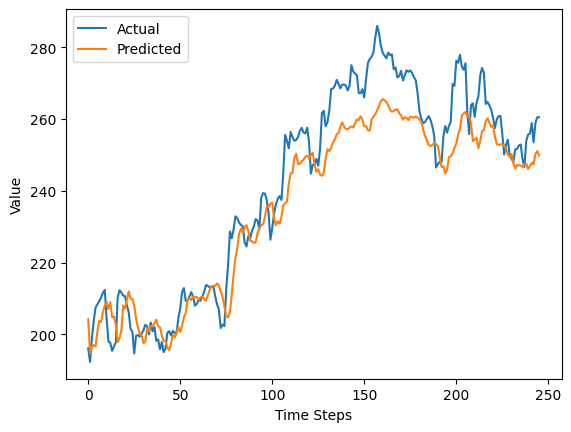

In [ ]:
plt.figure()
plt.plot(actual, label="Actual")
plt.plot(prediction, label="Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
model_birnn = Sequential([Bidirectional(SimpleRNN(50), input_shape=(window_size, 1)),Dense(1)])

model_birnn.compile(optimizer="adam", loss="mse")
model_birnn.summary()

history_bi = model_birnn.fit(X_train, y_train, epochs=10, batch_size=32,validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100)            │         5,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0164 - val_loss: 0.0131
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0021 - val_loss: 0.0041
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0014 - val_loss: 0.0054
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0012 - val_loss: 0.0063
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 9.5913e-04 - val_loss: 0.0029
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.8328e-04 - val_loss: 0.0043
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.1015e-04 - val_loss: 0.0031
Epoch 8/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7.1488e-04 - val_loss: 0.0030
Epoch 9/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.5404e-04 - val_loss: 0.0015
Epoch 10/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 6.2712e-04 - val_loss: 0.0027


In [ ]:
prediction = model_birnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f"Predicted: {prediction[i][0]:.2f}, Actual: {actual[i][0]:.2f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step
Predicted: 201.88, Actual: 196.13
Predicted: 200.44, Actual: 192.32
Predicted: 193.93, Actual: 198.87
Predicted: 201.85, Actual: 203.71
Predicted: 196.92, Actual: 207.47
Predicted: 208.05, Actual: 208.37
Predicted: 204.48, Actual: 209.23
Predicted: 205.63, Actual: 210.29
Predicted: 208.00, Actual: 211.58
Predicted: 205.31, Actual: 212.39
Predicted: 206.21, Actual: 204.46
Predicted: 204.97, Actual: 198.03
Predicted: 203.02, Actual: 197.65
Predicted: 194.33, Actual: 195.40
Predicted: 201.99, Actual: 196.63
Predicted: 195.47, Actual: 197.67
Predicted: 202.99, Actual: 210.15
Predicted: 206.30, Actual: 212.28
Predicted: 212.11, Actual: 211.69
Predicted: 201.71, Actual: 210.81
Predicted: 207.53, Actual: 210.62
Predicted: 209.22, Actual: 208.15
Predicted: 201.13, Actual: 206.23
Predicted: 209.40, Actual: 201.48
Predicted: 202.95, Actual: 200.75
Predicted: 203.70, Actual: 194.68
Predicted: 200.16, Actual: 199.60
Predicted: 201.89, Actual: 199.81
Predicted

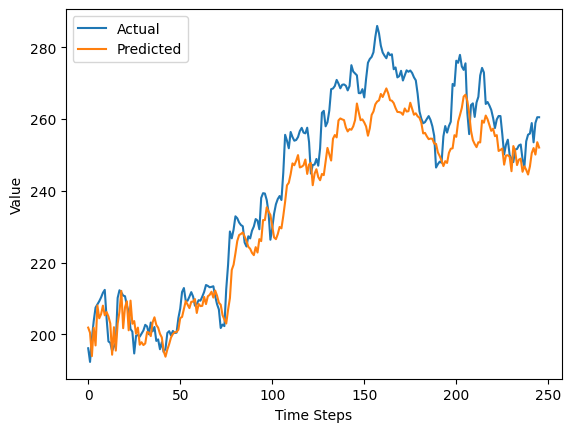

In [ ]:
plt.figure()
plt.plot(actual, label="Actual")
plt.plot(prediction, label="Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
batch = 32

model_stateful = Sequential([Input(batch_shape=(batch, window_size, 1)),SimpleRNN(50, stateful=True),Dense(1)])

model_stateful.compile(optimizer="adam", loss="mse")
model_stateful.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (32, 50)               │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 1)                │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
batch = 32

train_len = len(X_train) - (len(X_train) % batch)

X_train_s = X_train[:train_len]
y_train_s = y_train[:train_len]

print("Trimmed training shape:", X_train_s.shape)


Trimmed training shape: (960, 30, 1)


In [ ]:
train_len

960

In [ ]:
stateful_losses = []

for epoch in range(10):
    print(f"Epoch: {epoch+1}")

    history = model_stateful.fit(X_train_s,y_train_s,batch_size=batch,epochs=1,shuffle=False)

    # Store loss
    stateful_losses.append(history.history['loss'][0])

    # Reset RNN states after each epoch
    for layer in model_stateful.layers:
        if hasattr(layer, "reset_states"):
            layer.reset_states()

Epoch: 1
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0329
Epoch: 2
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0253
Epoch: 3
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071
Epoch: 4
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023
Epoch: 5
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013
Epoch: 6
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0011    
Epoch: 7
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.8659e-04
Epoch: 8
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.4944e-04
Epoch: 9
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0212e-04
Epoch: 10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.5495e-04


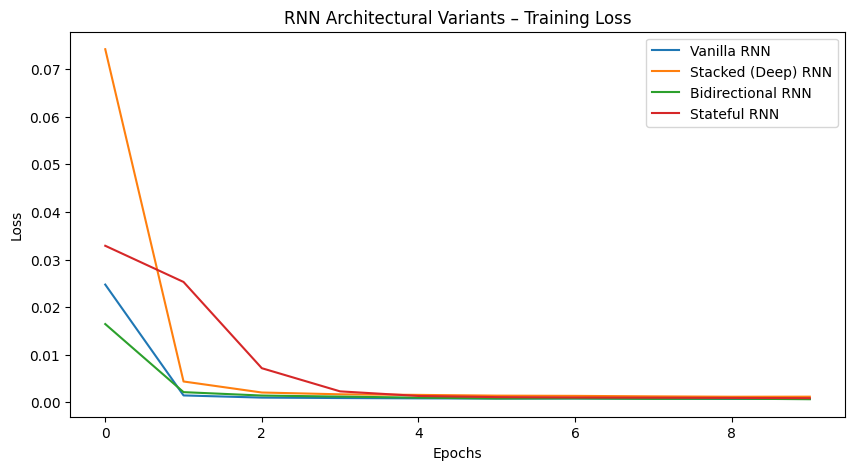

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(history_rnn.history['loss'], label='Vanilla RNN')
plt.plot(history_deep.history['loss'], label='Stacked (Deep) RNN')
plt.plot(history_bi.history['loss'], label='Bidirectional RNN')
plt.plot(stateful_losses, label='Stateful RNN')

plt.title("RNN Architectural Variants – Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()